# Backtest temporal tabular score strategies

This notebook evaluates all temporal tabular runs listed in `outputs/tables/temporal_tabular_experiment_comparison.csv` with the same validation/test score-strategy protocol used in `11_train_dl_xgb_and_evaluate_score_strategies.ipynb`.

Each model contributes two saved scores: `classifier = P(top) - P(bottom)` and `er_train`, the class-probability weighted return score saved by the training script.


In [1]:
# Cell 1: Imports, configuration, and paths

from __future__ import annotations

from pathlib import Path
import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

pd.set_option("display.max_columns", 140)
pd.set_option("display.width", 200)


def find_repo_root(start: Path | None = None) -> Path:
    start = (start or Path.cwd()).resolve()
    for path in [start] + list(start.parents):
        if (path / "outputs").exists() and (path / "scripts").exists():
            return path
    raise FileNotFoundError("Could not infer repo root. Run this notebook from the repo or notebooks/ folder.")


REPO_ROOT = find_repo_root()
PREDICTION_DIR = REPO_ROOT / "outputs/predictions"
TABLE_DIR = REPO_ROOT / "outputs/tables"
COMPARISON_PATH = TABLE_DIR / "temporal_tabular_experiment_comparison.csv"
BACKTEST_DIR = REPO_ROOT / "outputs/backtests/temporal_tabular_score_strategies"
FIGURE_DIR = BACKTEST_DIR / "figures"
for directory in [TABLE_DIR, BACKTEST_DIR, FIGURE_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

KEY_COLUMNS = ["PERMNO", "MthCalDt"]
BASE_COLUMNS = ["PERMNO", "gvkey", "MthCalDt", "split", "target_ret_1m", "target_quintile", "top_bottom_label"]
PROBABILITY_COLUMNS = ["prob_temporal_tabular_bottom", "prob_temporal_tabular_middle", "prob_temporal_tabular_top"]
SCORE_SOURCE_COLUMNS = ["prediction_temporal_tabular_classifier_score", "prediction_temporal_tabular_er_train_score"]
CLASS_LABELS = ["bottom", "middle", "top"]
SELECTION_COST_BPS = 10.0

print(f"Repo root: {REPO_ROOT}")
print(f"Comparison table: {COMPARISON_PATH}")
print(f"Backtest output directory: {BACKTEST_DIR}")


Repo root: /home/aturin/ML/ML_For_Finance_Project-AxelTurinPlessia-362559-ClementMeddeb-346164
Comparison table: /home/aturin/ML/ML_For_Finance_Project-AxelTurinPlessia-362559-ClementMeddeb-346164/outputs/tables/temporal_tabular_experiment_comparison.csv
Backtest output directory: /home/aturin/ML/ML_For_Finance_Project-AxelTurinPlessia-362559-ClementMeddeb-346164/outputs/backtests/temporal_tabular_score_strategies


In [2]:
# Cell 2: Load temporal tabular experiment registry and prediction artifacts

if not COMPARISON_PATH.exists():
    raise FileNotFoundError(f"Missing temporal tabular comparison table: {COMPARISON_PATH}")

comparison = pd.read_csv(COMPARISON_PATH).drop_duplicates("run_name").copy()
comparison["prediction_path"] = comparison["run_name"].map(lambda run: PREDICTION_DIR / f"{run}_predictions.parquet")
comparison["prediction_exists"] = comparison["prediction_path"].map(Path.exists)
missing = comparison.loc[~comparison["prediction_exists"], ["run_name", "prediction_path"]]
if not missing.empty:
    raise FileNotFoundError("Missing prediction file(s):\n" + missing.to_string(index=False))


def short_run_label(run_name: str) -> str:
    label = run_name.removeprefix("temporal_tabular_")
    label = label.replace("transformer_seed362559", "default_seed362559")
    label = re.sub(r"[^0-9a-zA-Z_]+", "_", label)
    return label.strip("_")


predictions = None
score_columns: dict[str, str] = {}
score_to_run_label: dict[str, str] = {}
run_label_to_name: dict[str, str] = {}
coverage_rows = []

for row in comparison.itertuples(index=False):
    run_name = row.run_name
    run_label = short_run_label(run_name)
    run_label_to_name[run_label] = run_name
    path = Path(row.prediction_path)
    run_df = pd.read_parquet(path)
    run_df["MthCalDt"] = pd.to_datetime(run_df["MthCalDt"], errors="raise")
    run_df["split"] = run_df["split"].astype(str)

    required = BASE_COLUMNS + PROBABILITY_COLUMNS + SCORE_SOURCE_COLUMNS
    missing_cols = [col for col in required if col not in run_df.columns]
    if missing_cols:
        raise ValueError(f"{path.name} is missing required columns: {missing_cols}")
    if run_df.duplicated(KEY_COLUMNS).any():
        raise ValueError(f"{path.name} has duplicate PERMNO-MthCalDt rows.")

    if predictions is None:
        predictions = run_df[BASE_COLUMNS].copy()
    else:
        key_check = predictions[KEY_COLUMNS].merge(run_df[KEY_COLUMNS], on=KEY_COLUMNS, how="outer", indicator=True)
        if not key_check["_merge"].eq("both").all():
            raise ValueError(f"Prediction keys in {path.name} do not match the first loaded temporal run.")

    renamed = run_df[KEY_COLUMNS + PROBABILITY_COLUMNS + SCORE_SOURCE_COLUMNS].rename(
        columns={
            "prob_temporal_tabular_bottom": f"prob_{run_label}_bottom",
            "prob_temporal_tabular_middle": f"prob_{run_label}_middle",
            "prob_temporal_tabular_top": f"prob_{run_label}_top",
            "prediction_temporal_tabular_classifier_score": f"score_{run_label}_classifier",
            "prediction_temporal_tabular_er_train_score": f"score_{run_label}_er_train",
        }
    )
    predictions = predictions.merge(renamed, on=KEY_COLUMNS, how="left", validate="one_to_one")

    for score_type in ["classifier", "er_train"]:
        score_label = f"{run_label}_{score_type}"
        score_columns[score_label] = f"score_{run_label}_{score_type}"
        score_to_run_label[score_label] = run_label

    coverage_rows.append(
        {
            "run_name": run_name,
            "run_label": run_label,
            "rows": len(run_df),
            "first_month": run_df["MthCalDt"].min(),
            "last_month": run_df["MthCalDt"].max(),
            "classifier_nonnull": int(run_df["prediction_temporal_tabular_classifier_score"].notna().sum()),
            "er_train_nonnull": int(run_df["prediction_temporal_tabular_er_train_score"].notna().sum()),
        }
    )

if predictions is None:
    raise ValueError("No prediction files were loaded.")

predictions = predictions.sort_values(["MthCalDt", "PERMNO"]).reset_index(drop=True)
coverage = pd.DataFrame(coverage_rows)
comparison.to_csv(TABLE_DIR / "temporal_tabular_backtest_loaded_runs.csv", index=False)
coverage.to_csv(TABLE_DIR / "temporal_tabular_backtest_prediction_coverage.csv", index=False)
predictions.to_parquet(PREDICTION_DIR / "temporal_tabular_backtest_predictions.parquet", index=False)

display(comparison[["run_name", "architecture_preset", "tabular_branch", "best_epoch", "validation_classifier_rank_ic_mean", "validation_er_train_rank_ic_mean", "test_classifier_rank_ic_mean", "test_er_train_rank_ic_mean", "prediction_path"]])
display(predictions.groupby("split", observed=True).agg(rows=("PERMNO", "size"), first_month=("MthCalDt", "min"), last_month=("MthCalDt", "max"), stocks=("PERMNO", "nunique")))
display(coverage)
print(f"Merged prediction table: {predictions.shape[0]:,} rows x {predictions.shape[1]:,} columns")


,run_name,architecture_preset,tabular_branch,best_epoch,validation_classifier_rank_ic_mean,validation_er_train_rank_ic_mean,test_classifier_rank_ic_mean,test_er_train_rank_ic_mean,prediction_path
0,temporal_tabular_tiny_random,tiny,ft_transformer,13,0.097549,0.079008,0.102822,0.083901,/home/aturin/ML/ML_For_Finance_Project-AxelTur...
1,temporal_tabular_small_random,small,ft_transformer,3,0.093132,0.058306,0.089672,0.048017,/home/aturin/ML/ML_For_Finance_Project-AxelTur...
2,temporal_tabular_small_mlp_branch,small,mlp,3,0.091212,0.050567,0.094774,0.066228,/home/aturin/ML/ML_For_Finance_Project-AxelTur...
3,temporal_tabular_transformer_seed362559,default,ft_transformer,1,0.088519,0.053489,0.101740,0.058755,/home/aturin/ML/ML_For_Finance_Project-AxelTur...
4,temporal_tabular_small_ft_warmstart,small,ft_transformer,2,0.088037,0.050690,0.098577,0.072101,/home/aturin/ML/ML_For_Finance_Project-AxelTur...
5,temporal_tabular_small_mlp_warmstart,small,mlp,1,0.077250,0.041050,0.097488,0.074288,/home/aturin/ML/ML_For_Finance_Project-AxelTur...


,rows,first_month,last_month,stocks
split,,,,
test,868926,2015-12-31,2024-10-31,14523
train,1834902,1989-12-29,2010-11-30,19469
validation,405264,2010-12-31,2015-11-30,9129


,run_name,run_label,rows,first_month,last_month,classifier_nonnull,er_train_nonnull
0,temporal_tabular_tiny_random,tiny_random,3109092,1989-12-29,2024-10-31,3109092,3109092
1,temporal_tabular_small_random,small_random,3109092,1989-12-29,2024-10-31,3109092,3109092
2,temporal_tabular_small_mlp_branch,small_mlp_branch,3109092,1989-12-29,2024-10-31,3109092,3109092
3,temporal_tabular_transformer_seed362559,default_seed362559,3109092,1989-12-29,2024-10-31,3109092,3109092
4,temporal_tabular_small_ft_warmstart,small_ft_warmstart,3109092,1989-12-29,2024-10-31,3109092,3109092
5,temporal_tabular_small_mlp_warmstart,small_mlp_warmstart,3109092,1989-12-29,2024-10-31,3109092,3109092


Merged prediction table: 3,109,092 rows x 37 columns


In [3]:
# Cell 3: Monthly Rank IC diagnostics


def monthly_rank_ic(data: pd.DataFrame, score_col: str, target_col: str = "target_ret_1m", date_col: str = "MthCalDt", split_col: str = "split") -> pd.DataFrame:
    rows = []
    for (split, month), part in data.groupby([split_col, date_col], sort=True, observed=True):
        scores = pd.to_numeric(part[score_col], errors="coerce")
        target = pd.to_numeric(part[target_col], errors="coerce")
        valid = scores.notna() & target.notna()
        if valid.sum() < 5 or scores[valid].nunique() <= 1 or target[valid].nunique() <= 1:
            ic = np.nan
        else:
            ic = scores[valid].corr(target[valid], method="spearman")
        rows.append({"split": split, "month": month, "score_name": score_col, "rank_ic": ic, "n_stocks": int(valid.sum())})
    return pd.DataFrame(rows)


def summarize_rank_ic(monthly_ic: pd.DataFrame) -> pd.DataFrame:
    summary = (
        monthly_ic.dropna(subset=["rank_ic"])
        .groupby(["score_label", "split"], observed=True)["rank_ic"]
        .agg(mean_rank_ic="mean", std_rank_ic="std", months="count")
        .reset_index()
    )
    summary["rank_ic_tstat"] = summary["mean_rank_ic"] / summary["std_rank_ic"] * np.sqrt(summary["months"])
    return summary.sort_values(["split", "mean_rank_ic"], ascending=[True, False])


monthly_ic_frames = []
for label, col in score_columns.items():
    tmp = monthly_rank_ic(predictions, col)
    tmp["score_label"] = label
    tmp["run_label"] = score_to_run_label[label]
    tmp["run_name"] = tmp["run_label"].map(run_label_to_name)
    tmp["score_type"] = "er_train" if label.endswith("_er_train") else "classifier"
    monthly_ic_frames.append(tmp)

monthly_ic_all = pd.concat(monthly_ic_frames, ignore_index=True)
rank_ic_summary = summarize_rank_ic(monthly_ic_all)
rank_ic_summary["run_label"] = rank_ic_summary["score_label"].map(score_to_run_label)
rank_ic_summary["run_name"] = rank_ic_summary["run_label"].map(run_label_to_name)
rank_ic_summary["score_type"] = np.where(rank_ic_summary["score_label"].str.endswith("_er_train"), "er_train", "classifier")

monthly_ic_all.to_csv(BACKTEST_DIR / "temporal_tabular_score_monthly_rank_ic.csv", index=False)
rank_ic_summary.to_csv(BACKTEST_DIR / "temporal_tabular_score_rank_ic_summary.csv", index=False)
validation_rank_ic = rank_ic_summary.loc[rank_ic_summary["split"].eq("validation")].sort_values("mean_rank_ic", ascending=False).reset_index(drop=True)
validation_rank_ic.to_csv(BACKTEST_DIR / "validation_temporal_tabular_score_rank_ic_ranking.csv", index=False)
display(validation_rank_ic)


,score_label,split,mean_rank_ic,std_rank_ic,months,rank_ic_tstat,run_label,run_name,score_type
0,tiny_random_classifier,validation,0.097549,0.100286,60,7.534537,tiny_random,temporal_tabular_tiny_random,classifier
1,small_random_classifier,validation,0.093132,0.110921,60,6.503703,small_random,temporal_tabular_small_random,classifier
2,small_mlp_branch_classifier,validation,0.091212,0.097040,60,7.280740,small_mlp_branch,temporal_tabular_small_mlp_branch,classifier
3,default_seed362559_classifier,validation,0.088519,0.099705,60,6.876927,default_seed362559,temporal_tabular_transformer_seed362559,classifier
4,small_ft_warmstart_classifier,validation,0.088037,0.081325,60,8.385273,small_ft_warmstart,temporal_tabular_small_ft_warmstart,classifier
5,tiny_random_er_train,validation,0.079008,0.083235,60,7.352566,tiny_random,temporal_tabular_tiny_random,er_train
6,small_mlp_warmstart_classifier,validation,0.077250,0.089721,60,6.669270,small_mlp_warmstart,temporal_tabular_small_mlp_warmstart,classifier
7,small_random_er_train,validation,0.058306,0.087317,60,5.172353,small_random,temporal_tabular_small_random,er_train
8,default_seed362559_er_train,validation,0.053489,0.125252,60,3.307935,default_seed362559,temporal_tabular_transformer_seed362559,er_train
9,small_ft_warmstart_er_train,validation,0.050690,0.094274,60,4.164906,small_ft_warmstart,temporal_tabular_small_ft_warmstart,er_train


In [4]:
# Cell 4: Portfolio construction helpers


def make_weights_for_month(part: pd.DataFrame, score_col: str, rule: str, q: float = 0.20, short_exposure: float = 1.0, long_exposure: float = 1.0, sign_gate: bool = False, threshold_gate: bool = False, zero_threshold: float = 0.0) -> pd.Series:
    if sign_gate and threshold_gate:
        raise ValueError("Use either sign_gate or threshold_gate, not both.")
    scores = pd.to_numeric(part[score_col], errors="coerce")
    valid = scores.notna()
    weights = pd.Series(0.0, index=part.index)
    if valid.sum() < 10:
        return weights
    ranks = scores[valid].rank(method="first", pct=True)
    long_idx = ranks[ranks >= 1 - q].index
    short_idx = ranks[ranks <= q].index
    if sign_gate:
        long_idx = long_idx[scores.loc[long_idx] > 0]
        short_idx = short_idx[scores.loc[short_idx] < 0]
    elif threshold_gate:
        long_idx = long_idx[scores.loc[long_idx] > zero_threshold]
        short_idx = short_idx[scores.loc[short_idx] < -zero_threshold]
    if rule == "long_only":
        if len(long_idx) > 0:
            weights.loc[long_idx] = 1.0 / len(long_idx)
        return weights
    if rule == "long_short":
        le, se = long_exposure, short_exposure
    elif rule == "gross_normalized_long_short":
        le, se = 0.5, 0.5
    elif rule == "long_short_130_30":
        le, se = 1.3, 0.3
    else:
        raise ValueError(f"Unknown rule: {rule}")
    if len(long_idx) > 0:
        weights.loc[long_idx] = le / len(long_idx)
    if len(short_idx) > 0:
        weights.loc[short_idx] = -se / len(short_idx)
    return weights


def build_portfolio_returns(data: pd.DataFrame, score_label: str, score_col: str, rule: str, q: float = 0.20, sign_gate: bool = False, threshold_gate: bool = False, zero_threshold: float = 0.0, one_way_cost_bps: float = 0.0, target_col: str = "target_ret_1m", date_col: str = "MthCalDt", split_col: str = "split") -> pd.DataFrame:
    rows = []
    previous_weights_by_split: dict[str, pd.Series] = {}
    data = data.sort_values([split_col, date_col, "PERMNO"]).copy()
    for (split, month), part in data.groupby([split_col, date_col], sort=True, observed=True):
        weights = make_weights_for_month(part, score_col=score_col, rule=rule, q=q, sign_gate=sign_gate, threshold_gate=threshold_gate, zero_threshold=zero_threshold)
        returns = pd.to_numeric(part[target_col], errors="coerce").fillna(0.0)
        gross_return = float((weights * returns).sum())
        long_weight = weights.clip(lower=0).sum()
        short_weight = -weights.clip(upper=0).sum()
        gross_exposure = weights.abs().sum()
        net_exposure = weights.sum()
        long_return = float((weights.clip(lower=0) * returns).sum() / long_weight) if long_weight > 0 else np.nan
        short_leg_contribution = float((weights.clip(upper=0) * returns).sum()) if short_weight > 0 else np.nan
        short_leg_return = float(short_leg_contribution / short_weight) if short_weight > 0 else np.nan
        current_weights = pd.Series(weights.values, index=part["PERMNO"].values)
        previous_weights = previous_weights_by_split.get(split)
        if previous_weights is None:
            turnover = float(current_weights.abs().sum())
        else:
            aligned = pd.concat([previous_weights.rename("prev"), current_weights.rename("curr")], axis=1).fillna(0.0)
            turnover = float((aligned["curr"] - aligned["prev"]).abs().sum())
        cost = (one_way_cost_bps / 10_000.0) * turnover
        rows.append({"split": split, "month": month, "score_label": score_label, "score_col": score_col, "rule": rule, "q": q, "sign_gate": sign_gate, "threshold_gate": threshold_gate, "zero_threshold": zero_threshold, "one_way_cost_bps": one_way_cost_bps, "gross_return": gross_return, "turnover": turnover, "trading_cost": cost, "net_return": gross_return - cost, "long_weight": float(long_weight), "short_weight": float(short_weight), "gross_exposure": float(gross_exposure), "net_exposure": float(net_exposure), "long_leg_return": long_return, "short_leg_return": short_leg_return, "short_leg_contribution": short_leg_contribution, "n_long": int((weights > 0).sum()), "n_short": int((weights < 0).sum())})
        previous_weights_by_split[split] = current_weights
    return pd.DataFrame(rows)


In [5]:
# Cell 5: Portfolio performance summary helpers


def max_drawdown(returns: pd.Series) -> float:
    wealth = (1.0 + returns.fillna(0.0)).cumprod()
    return float((wealth / wealth.cummax() - 1.0).min())


def annualized_return(monthly_returns: pd.Series) -> float:
    monthly_returns = monthly_returns.dropna()
    if len(monthly_returns) == 0:
        return np.nan
    total = (1.0 + monthly_returns).prod()
    if total <= 0:
        return np.nan
    years = len(monthly_returns) / 12.0
    return float(total ** (1.0 / years) - 1.0)


def annualized_volatility(monthly_returns: pd.Series) -> float:
    monthly_returns = monthly_returns.dropna()
    if len(monthly_returns) <= 1:
        return np.nan
    return float(monthly_returns.std() * np.sqrt(12))


def sharpe_ratio(monthly_returns: pd.Series) -> float:
    ann_ret = annualized_return(monthly_returns)
    ann_vol = annualized_volatility(monthly_returns)
    if ann_vol == 0 or pd.isna(ann_vol):
        return np.nan
    return float(ann_ret / ann_vol)


def summarize_portfolios(monthly: pd.DataFrame, return_col: str = "net_return") -> pd.DataFrame:
    rows = []
    group_cols = ["score_label", "rule", "q", "sign_gate", "threshold_gate", "zero_threshold", "one_way_cost_bps", "split"]
    for keys, part in monthly.groupby(group_cols, observed=True):
        score_label, rule, q, sign_gate, threshold_gate, zero_threshold, cost_bps, split = keys
        rets = part[return_col]
        run_label = score_to_run_label.get(score_label)
        rows.append({"score_label": score_label, "run_label": run_label, "run_name": run_label_to_name.get(run_label), "score_type": "er_train" if score_label.endswith("_er_train") else "classifier", "rule": rule, "q": q, "sign_gate": sign_gate, "threshold_gate": threshold_gate, "zero_threshold": zero_threshold, "one_way_cost_bps": cost_bps, "split": split, "months": len(part), "annualized_return": annualized_return(rets), "annualized_volatility": annualized_volatility(rets), "sharpe": sharpe_ratio(rets), "max_drawdown": max_drawdown(rets), "mean_monthly_return": rets.mean(), "std_monthly_return": rets.std(), "average_turnover": part["turnover"].mean(), "average_gross_exposure": part["gross_exposure"].mean(), "average_net_exposure": part["net_exposure"].mean(), "average_long_weight": part["long_weight"].mean(), "average_short_weight": part["short_weight"].mean(), "average_n_long": part["n_long"].mean(), "average_n_short": part["n_short"].mean(), "average_long_leg_return": part["long_leg_return"].mean(), "average_short_leg_return": part["short_leg_return"].mean(), "average_short_leg_contribution": part["short_leg_contribution"].mean()})
    return pd.DataFrame(rows)


In [6]:
# Cell 6: Define score and strategy grid, then run validation/test backtests

THRESHOLD_GRID = [0.00, 0.01, 0.02]
strategy_grid = [
    {"rule": "long_only", "q": 0.20, "sign_gate": False, "threshold_gate": False, "zero_threshold": 0.0},
    {"rule": "gross_normalized_long_short", "q": 0.20, "sign_gate": False, "threshold_gate": False, "zero_threshold": 0.0},
    {"rule": "long_short_130_30", "q": 0.20, "sign_gate": False, "threshold_gate": False, "zero_threshold": 0.0},
]
for tau in THRESHOLD_GRID:
    strategy_grid.append({"rule": "long_short", "q": 0.20, "sign_gate": False, "threshold_gate": True, "zero_threshold": tau})

cost_grid_bps = [0.0, 10.0, 25.0]
candidate_score_labels = list(score_columns)
print("Candidate score labels used in the strategy grid:")
print("\n".join(candidate_score_labels))

portfolio_frames = []
work_small = predictions.loc[predictions["split"].isin(["validation", "test"])].copy()
for score_label in candidate_score_labels:
    score_col = score_columns[score_label]
    for strategy in strategy_grid:
        bt_base = build_portfolio_returns(work_small, score_label=score_label, score_col=score_col, rule=strategy["rule"], q=strategy["q"], sign_gate=strategy["sign_gate"], threshold_gate=strategy["threshold_gate"], zero_threshold=strategy["zero_threshold"], one_way_cost_bps=0.0)
        for cost_bps in cost_grid_bps:
            bt = bt_base.copy()
            bt["one_way_cost_bps"] = cost_bps
            bt["trading_cost"] = (cost_bps / 10_000.0) * bt["turnover"]
            bt["net_return"] = bt["gross_return"] - bt["trading_cost"]
            portfolio_frames.append(bt)

portfolio_monthly = pd.concat(portfolio_frames, ignore_index=True)
portfolio_summary_net = summarize_portfolios(portfolio_monthly, return_col="net_return")
portfolio_summary_gross = summarize_portfolios(portfolio_monthly, return_col="gross_return").rename(columns={"annualized_return": "gross_annualized_return", "annualized_volatility": "gross_annualized_volatility", "sharpe": "gross_sharpe", "max_drawdown": "gross_max_drawdown", "mean_monthly_return": "gross_mean_monthly_return", "std_monthly_return": "gross_std_monthly_return"})
merge_cols = ["score_label", "rule", "q", "sign_gate", "threshold_gate", "zero_threshold", "one_way_cost_bps", "split"]
portfolio_summary = portfolio_summary_net.merge(portfolio_summary_gross[merge_cols + ["gross_annualized_return", "gross_annualized_volatility", "gross_sharpe", "gross_max_drawdown", "gross_mean_monthly_return", "gross_std_monthly_return"]], on=merge_cols, how="left")
portfolio_monthly.to_csv(BACKTEST_DIR / "temporal_tabular_score_strategy_monthly_returns.csv", index=False)
portfolio_summary.to_csv(BACKTEST_DIR / "temporal_tabular_score_strategy_performance_summary.csv", index=False)
display(portfolio_summary.head())


Candidate score labels used in the strategy grid:
tiny_random_classifier
tiny_random_er_train
small_random_classifier
small_random_er_train
small_mlp_branch_classifier
small_mlp_branch_er_train
default_seed362559_classifier
default_seed362559_er_train
small_ft_warmstart_classifier
small_ft_warmstart_er_train
small_mlp_warmstart_classifier
small_mlp_warmstart_er_train


,score_label,run_label,run_name,score_type,rule,q,sign_gate,threshold_gate,zero_threshold,one_way_cost_bps,split,months,annualized_return,annualized_volatility,sharpe,max_drawdown,mean_monthly_return,std_monthly_return,average_turnover,average_gross_exposure,average_net_exposure,average_long_weight,average_short_weight,average_n_long,average_n_short,average_long_leg_return,average_short_leg_return,average_short_leg_contribution,gross_annualized_return,gross_annualized_volatility,gross_sharpe,gross_max_drawdown,gross_mean_monthly_return,gross_std_monthly_return
0,default_seed362559_classifier,default_seed362559,temporal_tabular_transformer_seed362559,classifier,gross_normalized_long_short,0.2,False,False,0.0,0.0,test,107,0.074470,0.102882,0.723843,-0.286928,0.006444,0.029699,0.331840,1.0,-5.421011e-19,0.5,0.5,1624.757009,1623.757009,0.011844,0.001044,0.000522,0.074470,0.102882,0.723843,-0.286928,0.006444,0.029699
1,default_seed362559_classifier,default_seed362559,temporal_tabular_transformer_seed362559,classifier,gross_normalized_long_short,0.2,False,False,0.0,0.0,validation,60,0.072454,0.061093,1.185973,-0.075871,0.005999,0.017636,0.354932,1.0,-4.221160e-18,0.5,0.5,1351.516667,1350.516667,0.009820,0.002178,0.001089,0.072454,0.061093,1.185973,-0.075871,0.005999,0.017636
2,default_seed362559_classifier,default_seed362559,temporal_tabular_transformer_seed362559,classifier,gross_normalized_long_short,0.2,False,False,0.0,10.0,test,107,0.070217,0.102931,0.682181,-0.291595,0.006112,0.029714,0.331840,1.0,-5.421011e-19,0.5,0.5,1624.757009,1623.757009,0.011844,0.001044,0.000522,0.074470,0.102882,0.723843,-0.286928,0.006444,0.029699
3,default_seed362559_classifier,default_seed362559,temporal_tabular_transformer_seed362559,classifier,gross_normalized_long_short,0.2,False,False,0.0,10.0,validation,60,0.067917,0.061158,1.110509,-0.078424,0.005644,0.017655,0.354932,1.0,-4.221160e-18,0.5,0.5,1351.516667,1350.516667,0.009820,0.002178,0.001089,0.072454,0.061093,1.185973,-0.075871,0.005999,0.017636
4,default_seed362559_classifier,default_seed362559,temporal_tabular_transformer_seed362559,classifier,gross_normalized_long_short,0.2,False,False,0.0,25.0,test,107,0.063867,0.103007,0.620023,-0.298542,0.005614,0.029736,0.331840,1.0,-5.421011e-19,0.5,0.5,1624.757009,1623.757009,0.011844,0.001044,0.000522,0.074470,0.102882,0.723843,-0.286928,0.006444,0.029699


In [7]:
# Cell 7: Validation rankings by annualized return with composite score

VALIDATION_RANKING_COLUMNS = ["score_label", "run_name", "score_type", "rule", "q", "threshold_gate", "zero_threshold", "one_way_cost_bps", "validation_composite_score", "validation_rank_ic", "validation_rank_ic_tstat", "validation_net_sharpe", "validation_net_annualized_return", "validation_net_annualized_volatility", "average_turnover", "eligible_for_selection", "average_n_long", "average_n_short", "average_gross_exposure", "average_long_leg_return", "average_short_leg_return", "average_short_leg_contribution", "max_drawdown"]


def build_validation_selection_ranking(portfolio_summary: pd.DataFrame, validation_rank_ic: pd.DataFrame) -> pd.DataFrame:
    rank_ic_lookup = validation_rank_ic[["score_label", "mean_rank_ic", "rank_ic_tstat"]].rename(columns={"mean_rank_ic": "validation_rank_ic", "rank_ic_tstat": "validation_rank_ic_tstat"})
    ranking = portfolio_summary.loc[portfolio_summary["split"].eq("validation")].merge(rank_ic_lookup, on="score_label", how="left", validate="many_to_one").copy()
    ranking["validation_net_sharpe"] = ranking["sharpe"]
    ranking["validation_net_annualized_return"] = ranking["annualized_return"]
    ranking["validation_net_annualized_volatility"] = ranking["annualized_volatility"]
    ranking["eligible_for_selection"] = ranking["validation_rank_ic"].notna() & ranking["validation_net_sharpe"].notna() & ranking["validation_net_annualized_return"].notna() & ranking["validation_net_annualized_volatility"].notna() & ranking["average_turnover"].notna() & ranking["average_turnover"].gt(0) & ranking["average_gross_exposure"].gt(0) & ranking["validation_net_annualized_volatility"].gt(0)
    ranking["validation_composite_score"] = ranking["validation_rank_ic"] + ranking["validation_net_sharpe"] + ranking["validation_net_annualized_return"] - ranking["average_turnover"] - ranking["validation_net_annualized_volatility"]
    ranking.loc[~ranking["eligible_for_selection"], "validation_composite_score"] = -np.inf
    return ranking.sort_values(["one_way_cost_bps", "eligible_for_selection", "validation_net_annualized_return", "validation_net_sharpe", "validation_composite_score"], ascending=[True, False, False, False, False]).reset_index(drop=True)


validation_portfolios = build_validation_selection_ranking(portfolio_summary, validation_rank_ic)
validation_portfolios.to_csv(BACKTEST_DIR / "validation_temporal_tabular_score_strategy_ranking.csv", index=False)
validation_rankings_by_cost = {}
for cost in cost_grid_bps:
    ranking = validation_portfolios.loc[validation_portfolios["one_way_cost_bps"].eq(cost)].reset_index(drop=True)
    validation_rankings_by_cost[cost] = ranking
    ranking.to_csv(BACKTEST_DIR / f"validation_temporal_tabular_score_strategy_ranking_{int(cost)}bps.csv", index=False)
    print(f"Validation ranking by net annualized return at {cost:.0f} bps")
    display(ranking[VALIDATION_RANKING_COLUMNS].head(30))


Validation ranking by net annualized return at 0 bps


,score_label,run_name,score_type,rule,q,threshold_gate,zero_threshold,one_way_cost_bps,validation_composite_score,validation_rank_ic,validation_rank_ic_tstat,validation_net_sharpe,validation_net_annualized_return,validation_net_annualized_volatility,average_turnover,eligible_for_selection,average_n_long,average_n_short,average_gross_exposure,average_long_leg_return,average_short_leg_return,average_short_leg_contribution,max_drawdown
0,small_ft_warmstart_er_train,temporal_tabular_small_ft_warmstart,er_train,long_short,0.2,True,0.01,0.0,2.689663,0.050690,4.164906,2.964651,1.723218,0.581255,1.467640,True,1351.516667,5.433333,1.916667,0.010186,0.099761,0.099761,-0.543462
1,small_mlp_warmstart_er_train,temporal_tabular_small_mlp_warmstart,er_train,long_short,0.2,True,0.01,0.0,1.351655,0.041050,2.531480,2.347719,1.619898,0.689988,1.967024,True,1351.516667,4.350000,1.833333,0.008700,0.112006,0.112006,-0.528000
2,small_random_er_train,temporal_tabular_small_random,er_train,long_short,0.2,True,0.01,0.0,0.262116,0.058306,5.172353,1.379042,0.748611,0.542849,1.380994,True,1351.516667,15.383333,2.000000,0.011213,0.050141,0.050141,-0.581122
3,small_mlp_branch_er_train,temporal_tabular_small_mlp_branch,er_train,long_short,0.2,True,0.01,0.0,-0.337126,0.050567,3.635593,1.019245,0.368150,0.361199,1.413889,True,1351.516667,20.433333,2.000000,0.010024,0.022013,0.022013,-0.291155
4,small_random_er_train,temporal_tabular_small_random,er_train,long_short,0.2,True,0.00,0.0,0.417552,0.058306,5.172353,1.257509,0.308247,0.245125,0.961385,True,1351.516667,167.283333,2.000000,0.011213,0.013926,0.013926,-0.208097
5,default_seed362559_er_train,temporal_tabular_transformer_seed362559,er_train,long_short,0.2,True,0.01,0.0,0.144685,0.053489,3.307935,1.359546,0.304766,0.224167,1.348949,True,1351.516667,145.983333,1.983333,0.010292,0.014444,0.014444,-0.212357
6,default_seed362559_er_train,temporal_tabular_transformer_seed362559,er_train,long_short,0.2,True,0.02,0.0,-0.995613,0.053489,3.307935,0.866203,0.291842,0.336921,1.870226,True,610.150000,50.033333,1.916667,0.013055,0.014596,0.014596,-0.351469
7,small_ft_warmstart_er_train,temporal_tabular_small_ft_warmstart,er_train,long_short,0.2,True,0.00,0.0,0.607442,0.050690,4.164906,1.460960,0.290883,0.199104,0.995988,True,1351.516667,138.916667,2.000000,0.010186,0.012939,0.012939,-0.165099
8,default_seed362559_er_train,temporal_tabular_transformer_seed362559,er_train,long_short,0.2,True,0.00,0.0,0.287632,0.053489,3.307935,1.369072,0.249527,0.182260,1.202196,True,1351.516667,387.100000,2.000000,0.010292,0.009846,0.009846,-0.241024
9,small_mlp_warmstart_er_train,temporal_tabular_small_mlp_warmstart,er_train,long_short,0.2,True,0.00,0.0,-0.674363,0.041050,2.531480,0.988544,0.237449,0.240201,1.701206,True,1351.516667,131.650000,2.000000,0.008700,0.011694,0.011694,-0.248226


Validation ranking by net annualized return at 10 bps


,score_label,run_name,score_type,rule,q,threshold_gate,zero_threshold,one_way_cost_bps,validation_composite_score,validation_rank_ic,validation_rank_ic_tstat,validation_net_sharpe,validation_net_annualized_return,validation_net_annualized_volatility,average_turnover,eligible_for_selection,average_n_long,average_n_short,average_gross_exposure,average_long_leg_return,average_short_leg_return,average_short_leg_contribution,max_drawdown
0,small_ft_warmstart_er_train,temporal_tabular_small_ft_warmstart,er_train,long_short,0.2,True,0.01,10.0,2.571715,0.050690,4.164906,2.890362,1.679304,0.581001,1.467640,True,1351.516667,5.433333,1.916667,0.010186,0.099761,0.099761,-0.544179
1,small_mlp_warmstart_er_train,temporal_tabular_small_mlp_warmstart,er_train,long_short,0.2,True,0.01,10.0,1.210237,0.041050,2.531480,2.264002,1.562247,0.690038,1.967024,True,1351.516667,4.350000,1.833333,0.008700,0.112006,0.112006,-0.532274
2,small_random_er_train,temporal_tabular_small_random,er_train,long_short,0.2,True,0.01,10.0,0.182977,0.058306,5.172353,1.327759,0.720702,0.542795,1.380994,True,1351.516667,15.383333,2.000000,0.011213,0.050141,0.050141,-0.582481
3,small_mlp_branch_er_train,temporal_tabular_small_mlp_branch,er_train,long_short,0.2,True,0.01,10.0,-0.421623,0.050567,3.635593,0.957166,0.345625,0.361092,1.413889,True,1351.516667,20.433333,2.000000,0.010024,0.022013,0.022013,-0.296060
4,small_random_er_train,temporal_tabular_small_random,er_train,long_short,0.2,True,0.00,10.0,0.341598,0.058306,5.172353,1.196483,0.293478,0.245284,0.961385,True,1351.516667,167.283333,2.000000,0.011213,0.013926,0.013926,-0.211179
5,default_seed362559_er_train,temporal_tabular_transformer_seed362559,er_train,long_short,0.2,True,0.01,10.0,0.032800,0.053489,3.307935,1.268160,0.284219,0.224119,1.348949,True,1351.516667,145.983333,1.983333,0.010292,0.014444,0.014444,-0.216196
6,small_ft_warmstart_er_train,temporal_tabular_small_ft_warmstart,er_train,long_short,0.2,True,0.00,10.0,0.517017,0.050690,4.164906,1.385558,0.275840,0.199082,0.995988,True,1351.516667,138.916667,2.000000,0.010186,0.012939,0.012939,-0.167484
7,default_seed362559_er_train,temporal_tabular_transformer_seed362559,er_train,long_short,0.2,True,0.02,10.0,-1.105937,0.053489,3.307935,0.783621,0.263726,0.336547,1.870226,True,610.150000,50.033333,1.916667,0.013055,0.014596,0.014596,-0.353686
8,default_seed362559_er_train,temporal_tabular_transformer_seed362559,er_train,long_short,0.2,True,0.00,10.0,0.175168,0.053489,3.307935,1.273989,0.231958,0.182072,1.202196,True,1351.516667,387.100000,2.000000,0.010292,0.009846,0.009846,-0.247628
9,tiny_random_er_train,temporal_tabular_tiny_random,er_train,long_short,0.2,True,0.00,10.0,0.317613,0.079008,7.352566,1.095020,0.223452,0.204062,0.875804,True,1351.516667,334.183333,2.000000,0.010761,0.008810,0.008810,-0.202454


Validation ranking by net annualized return at 25 bps


,score_label,run_name,score_type,rule,q,threshold_gate,zero_threshold,one_way_cost_bps,validation_composite_score,validation_rank_ic,validation_rank_ic_tstat,validation_net_sharpe,validation_net_annualized_return,validation_net_annualized_volatility,average_turnover,eligible_for_selection,average_n_long,average_n_short,average_gross_exposure,average_long_leg_return,average_short_leg_return,average_short_leg_contribution,max_drawdown
0,small_ft_warmstart_er_train,temporal_tabular_small_ft_warmstart,er_train,long_short,0.2,True,0.01,25.0,2.397922,0.050690,4.164906,2.780858,1.614641,0.580627,1.467640,True,1351.516667,5.433333,1.916667,0.010186,0.099761,0.099761,-0.545254
1,small_mlp_warmstart_er_train,temporal_tabular_small_mlp_warmstart,er_train,long_short,0.2,True,0.01,25.0,1.003348,0.041050,2.531480,2.141526,1.477920,0.690125,1.967024,True,1351.516667,4.350000,1.833333,0.008700,0.112006,0.112006,-0.540475
2,small_random_er_train,temporal_tabular_small_random,er_train,long_short,0.2,True,0.01,25.0,0.066375,0.058306,5.172353,1.252193,0.679593,0.542723,1.380994,True,1351.516667,15.383333,2.000000,0.011213,0.050141,0.050141,-0.584518
3,small_mlp_branch_er_train,temporal_tabular_small_mlp_branch,er_train,long_short,0.2,True,0.01,25.0,-0.546078,0.050567,3.635593,0.865714,0.312470,0.360939,1.413889,True,1351.516667,20.433333,2.000000,0.010024,0.022013,0.022013,-0.303368
4,small_random_er_train,temporal_tabular_small_random,er_train,long_short,0.2,True,0.00,25.0,0.229231,0.058306,5.172353,1.106228,0.271609,0.245527,0.961385,True,1351.516667,167.283333,2.000000,0.011213,0.013926,0.013926,-0.215785
5,default_seed362559_er_train,temporal_tabular_transformer_seed362559,er_train,long_short,0.2,True,0.01,25.0,-0.132253,0.053489,3.307935,1.133331,0.253947,0.224072,1.348949,True,1351.516667,145.983333,1.983333,0.010292,0.014444,0.014444,-0.221938
6,small_ft_warmstart_er_train,temporal_tabular_small_ft_warmstart,er_train,long_short,0.2,True,0.00,25.0,0.383109,0.050690,4.164906,1.273888,0.253574,0.199055,0.995988,True,1351.516667,138.916667,2.000000,0.010186,0.012939,0.012939,-0.171051
7,default_seed362559_er_train,temporal_tabular_transformer_seed362559,er_train,long_short,0.2,True,0.02,25.0,-1.267717,0.053489,3.307935,0.662444,0.222591,0.336014,1.870226,True,610.150000,50.033333,1.916667,0.013055,0.014596,0.014596,-0.370870
8,default_seed362559_er_train,temporal_tabular_transformer_seed362559,er_train,long_short,0.2,True,0.00,25.0,0.008638,0.053489,3.307935,1.133138,0.206022,0.181815,1.202196,True,1351.516667,387.100000,2.000000,0.010292,0.009846,0.009846,-0.257446
9,tiny_random_er_train,temporal_tabular_tiny_random,er_train,long_short,0.2,True,0.00,25.0,0.205150,0.079008,7.352566,1.001616,0.204551,0.204221,0.875804,True,1351.516667,334.183333,2.000000,0.010761,0.008810,0.008810,-0.210677


best_rank_ic: tiny_random_classifier


,bottom,middle,top
bottom,13057,68025,0
middle,6858,236261,0
top,8659,72404,0


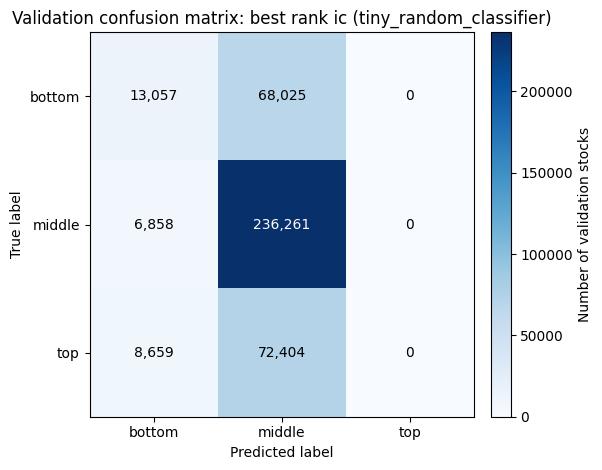

best_annualized_return: small_ft_warmstart_er_train


,bottom,middle,top
bottom,7774,73308,0
middle,3832,239287,0
top,4955,76108,0


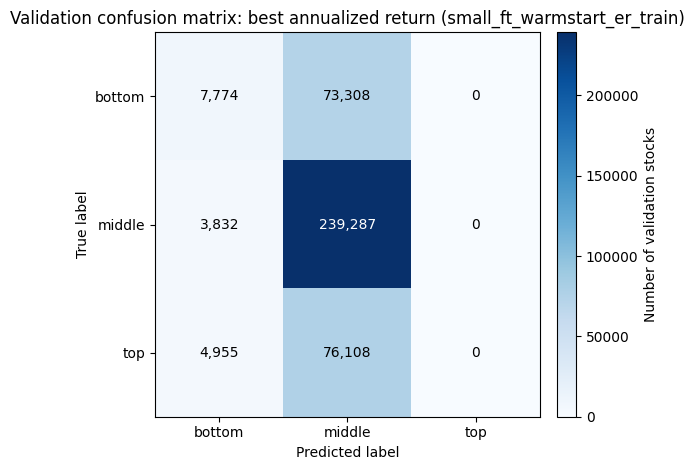

,score_label,run_label,run_name,validation_rows,accuracy,selection
0,tiny_random_classifier,tiny_random,temporal_tabular_tiny_random,405264,0.615199,best_rank_ic
1,small_ft_warmstart_er_train,small_ft_warmstart,temporal_tabular_small_ft_warmstart,405264,0.609630,best_annualized_return


In [8]:
# Cell 8: Validation confusion matrices for best selected score families


def validation_confusion_matrix_for_score(score_label: str) -> tuple[pd.DataFrame, pd.Series]:
    run_label = score_to_run_label[score_label]
    prob_cols = [f"prob_{run_label}_bottom", f"prob_{run_label}_middle", f"prob_{run_label}_top"]
    validation = predictions.loc[predictions["split"].eq("validation"), ["top_bottom_label"] + prob_cols].dropna().copy()
    validation["predicted_label"] = np.argmax(validation[prob_cols].to_numpy(dtype="float64"), axis=1)
    matrix = pd.crosstab(validation["top_bottom_label"], validation["predicted_label"], rownames=["True label"], colnames=["Predicted label"], dropna=False).reindex(index=[0, 1, 2], columns=[0, 1, 2], fill_value=0)
    matrix.index = CLASS_LABELS
    matrix.columns = CLASS_LABELS
    total = matrix.to_numpy().sum()
    summary = pd.Series({"score_label": score_label, "run_label": run_label, "run_name": run_label_to_name.get(run_label), "validation_rows": int(total), "accuracy": float(np.trace(matrix.to_numpy()) / total) if total else np.nan})
    return matrix, summary


def plot_confusion_heatmap(matrix: pd.DataFrame, title: str, path: Path | None = None) -> None:
    fig, ax = plt.subplots(figsize=(5.8, 4.8))
    values = matrix.to_numpy(dtype="float64")
    image = ax.imshow(values, cmap="Blues")
    fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04, label="Number of validation stocks")
    ax.set_xticks(np.arange(len(CLASS_LABELS)))
    ax.set_yticks(np.arange(len(CLASS_LABELS)))
    ax.set_xticklabels(CLASS_LABELS)
    ax.set_yticklabels(CLASS_LABELS)
    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")
    ax.set_title(title)
    threshold = values.max() / 2 if values.size and values.max() > 0 else 0
    for row in range(values.shape[0]):
        for col in range(values.shape[1]):
            color = "white" if values[row, col] > threshold else "black"
            ax.text(col, row, f"{int(values[row, col]):,}", ha="center", va="center", color=color, fontsize=10)
    fig.tight_layout()
    if path is not None:
        fig.savefig(path, dpi=160, bbox_inches="tight")
    plt.show()


best_rank_ic_label = validation_rank_ic.sort_values("mean_rank_ic", ascending=False).iloc[0]["score_label"]
best_annualized_return_label = validation_portfolios.sort_values(["annualized_return", "sharpe"], ascending=False).iloc[0]["score_label"]
confusion_outputs = []
for selection_name, score_label in [("best_rank_ic", best_rank_ic_label), ("best_annualized_return", best_annualized_return_label)]:
    matrix, summary = validation_confusion_matrix_for_score(score_label)
    summary["selection"] = selection_name
    confusion_outputs.append(summary)
    print(f"{selection_name}: {score_label}")
    display(matrix)
    matrix.to_csv(BACKTEST_DIR / f"validation_confusion_matrix_{selection_name}.csv")
    plot_confusion_heatmap(matrix, f"Validation confusion matrix: {selection_name.replace('_', ' ')} ({score_label})", FIGURE_DIR / f"validation_confusion_matrix_{selection_name}.png")
confusion_matrix_summary = pd.DataFrame(confusion_outputs)
confusion_matrix_summary.to_csv(BACKTEST_DIR / "validation_confusion_matrix_summary.csv", index=False)
display(confusion_matrix_summary)


In [9]:
# Cell 9: Choose the specification using validation only and report matching test rows

SPEC_COLUMNS = ["score_label", "rule", "q", "sign_gate", "threshold_gate", "zero_threshold", "one_way_cost_bps"]
SELECTION_SORT = ["validation_net_annualized_return", "validation_net_sharpe", "validation_composite_score"]
selection_table = validation_portfolios.loc[validation_portfolios["one_way_cost_bps"].eq(SELECTION_COST_BPS) & validation_portfolios["eligible_for_selection"]].sort_values(SELECTION_SORT, ascending=[False, False, False]).reset_index(drop=True)
if selection_table.empty:
    raise ValueError("No eligible validation strategies found.")
selection_table.to_csv(BACKTEST_DIR / "validation_temporal_tabular_selection_table_10bps.csv", index=False)
display(selection_table[VALIDATION_RANKING_COLUMNS].head(30))

chosen_spec = selection_table.iloc[0][SPEC_COLUMNS].to_dict()
pd.DataFrame([chosen_spec]).to_csv(BACKTEST_DIR / "chosen_validation_temporal_tabular_specification.csv", index=False)
chosen_test = portfolio_summary.loc[portfolio_summary["split"].eq("test") & portfolio_summary["score_label"].eq(chosen_spec["score_label"]) & portfolio_summary["rule"].eq(chosen_spec["rule"]) & np.isclose(portfolio_summary["q"].astype(float), float(chosen_spec["q"])) & portfolio_summary["sign_gate"].eq(bool(chosen_spec["sign_gate"])) & portfolio_summary["threshold_gate"].eq(bool(chosen_spec["threshold_gate"])) & np.isclose(portfolio_summary["zero_threshold"].astype(float), float(chosen_spec["zero_threshold"])) & np.isclose(portfolio_summary["one_way_cost_bps"].astype(float), float(chosen_spec["one_way_cost_bps"]))].reset_index(drop=True)
assert len(chosen_test) == 1, "Expected exactly one test row for the chosen specification."
chosen_test.to_csv(BACKTEST_DIR / "test_performance_of_chosen_validation_temporal_tabular_spec.csv", index=False)

top_validation_specs = selection_table.head(10)[SPEC_COLUMNS].copy()
test_selected_specs = top_validation_specs.merge(portfolio_summary.loc[portfolio_summary["split"].eq("test")], on=SPEC_COLUMNS, how="left")
test_selected_specs.to_csv(BACKTEST_DIR / "test_performance_of_top_validation_temporal_tabular_specs.csv", index=False)
print("Chosen validation specification:")
print(chosen_spec)
display(chosen_test)
display(test_selected_specs[SPEC_COLUMNS + ["run_name", "score_type", "annualized_return", "annualized_volatility", "sharpe", "max_drawdown", "average_turnover", "average_gross_exposure", "average_n_long", "average_n_short"]])


,score_label,run_name,score_type,rule,q,threshold_gate,zero_threshold,one_way_cost_bps,validation_composite_score,validation_rank_ic,validation_rank_ic_tstat,validation_net_sharpe,validation_net_annualized_return,validation_net_annualized_volatility,average_turnover,eligible_for_selection,average_n_long,average_n_short,average_gross_exposure,average_long_leg_return,average_short_leg_return,average_short_leg_contribution,max_drawdown
0,small_ft_warmstart_er_train,temporal_tabular_small_ft_warmstart,er_train,long_short,0.2,True,0.01,10.0,2.571715,0.050690,4.164906,2.890362,1.679304,0.581001,1.467640,True,1351.516667,5.433333,1.916667,0.010186,0.099761,0.099761,-0.544179
1,small_mlp_warmstart_er_train,temporal_tabular_small_mlp_warmstart,er_train,long_short,0.2,True,0.01,10.0,1.210237,0.041050,2.531480,2.264002,1.562247,0.690038,1.967024,True,1351.516667,4.350000,1.833333,0.008700,0.112006,0.112006,-0.532274
2,small_random_er_train,temporal_tabular_small_random,er_train,long_short,0.2,True,0.01,10.0,0.182977,0.058306,5.172353,1.327759,0.720702,0.542795,1.380994,True,1351.516667,15.383333,2.000000,0.011213,0.050141,0.050141,-0.582481
3,small_mlp_branch_er_train,temporal_tabular_small_mlp_branch,er_train,long_short,0.2,True,0.01,10.0,-0.421623,0.050567,3.635593,0.957166,0.345625,0.361092,1.413889,True,1351.516667,20.433333,2.000000,0.010024,0.022013,0.022013,-0.296060
4,small_random_er_train,temporal_tabular_small_random,er_train,long_short,0.2,True,0.00,10.0,0.341598,0.058306,5.172353,1.196483,0.293478,0.245284,0.961385,True,1351.516667,167.283333,2.000000,0.011213,0.013926,0.013926,-0.211179
5,default_seed362559_er_train,temporal_tabular_transformer_seed362559,er_train,long_short,0.2,True,0.01,10.0,0.032800,0.053489,3.307935,1.268160,0.284219,0.224119,1.348949,True,1351.516667,145.983333,1.983333,0.010292,0.014444,0.014444,-0.216196
6,small_ft_warmstart_er_train,temporal_tabular_small_ft_warmstart,er_train,long_short,0.2,True,0.00,10.0,0.517017,0.050690,4.164906,1.385558,0.275840,0.199082,0.995988,True,1351.516667,138.916667,2.000000,0.010186,0.012939,0.012939,-0.167484
7,default_seed362559_er_train,temporal_tabular_transformer_seed362559,er_train,long_short,0.2,True,0.02,10.0,-1.105937,0.053489,3.307935,0.783621,0.263726,0.336547,1.870226,True,610.150000,50.033333,1.916667,0.013055,0.014596,0.014596,-0.353686
8,default_seed362559_er_train,temporal_tabular_transformer_seed362559,er_train,long_short,0.2,True,0.00,10.0,0.175168,0.053489,3.307935,1.273989,0.231958,0.182072,1.202196,True,1351.516667,387.100000,2.000000,0.010292,0.009846,0.009846,-0.247628
9,tiny_random_er_train,temporal_tabular_tiny_random,er_train,long_short,0.2,True,0.00,10.0,0.317613,0.079008,7.352566,1.095020,0.223452,0.204062,0.875804,True,1351.516667,334.183333,2.000000,0.010761,0.008810,0.008810,-0.202454


Chosen validation specification:
{'score_label': 'small_ft_warmstart_er_train', 'rule': 'long_short', 'q': 0.2, 'sign_gate': False, 'threshold_gate': True, 'zero_threshold': 0.01, 'one_way_cost_bps': 10.0}


,score_label,run_label,run_name,score_type,rule,q,sign_gate,threshold_gate,zero_threshold,one_way_cost_bps,split,months,annualized_return,annualized_volatility,sharpe,max_drawdown,mean_monthly_return,std_monthly_return,average_turnover,average_gross_exposure,average_net_exposure,average_long_weight,average_short_weight,average_n_long,average_n_short,average_long_leg_return,average_short_leg_return,average_short_leg_contribution,gross_annualized_return,gross_annualized_volatility,gross_sharpe,gross_max_drawdown,gross_mean_monthly_return,gross_std_monthly_return
0,small_ft_warmstart_er_train,small_ft_warmstart,temporal_tabular_small_ft_warmstart,er_train,long_short,0.2,False,True,0.01,10.0,test,107,0.747019,0.536715,1.391836,-0.92319,0.063719,0.154936,1.37787,2.0,2.075994e-17,1.0,1.0,1624.757009,34.205607,0.01137,0.053727,0.053727,0.775226,0.536905,1.443879,-0.921159,0.065097,0.154991


,score_label,rule,q,sign_gate,threshold_gate,zero_threshold,one_way_cost_bps,run_name,score_type,annualized_return,annualized_volatility,sharpe,max_drawdown,average_turnover,average_gross_exposure,average_n_long,average_n_short
0,small_ft_warmstart_er_train,long_short,0.2,False,True,0.01,10.0,temporal_tabular_small_ft_warmstart,er_train,0.747019,0.536715,1.391836,-0.923190,1.377870,2.000000,1624.757009,34.205607
1,small_mlp_warmstart_er_train,long_short,0.2,False,True,0.01,10.0,temporal_tabular_small_mlp_warmstart,er_train,1.469412,0.448286,3.277844,-0.256100,2.079685,1.934579,1624.757009,42.084112
2,small_random_er_train,long_short,0.2,False,True,0.01,10.0,temporal_tabular_small_random,er_train,0.317986,0.563872,0.563934,-0.852873,1.235219,2.000000,1624.757009,42.457944
3,small_mlp_branch_er_train,long_short,0.2,False,True,0.01,10.0,temporal_tabular_small_mlp_branch,er_train,0.483770,0.372570,1.298469,-0.712836,1.175091,2.000000,1624.757009,80.046729
4,small_random_er_train,long_short,0.2,False,True,0.00,10.0,temporal_tabular_small_random,er_train,0.202033,0.356194,0.567200,-0.757416,0.906366,2.000000,1624.757009,303.897196
5,default_seed362559_er_train,long_short,0.2,False,True,0.01,10.0,temporal_tabular_transformer_seed362559,er_train,0.352322,0.266217,1.323440,-0.442171,1.350368,2.000000,1624.757009,263.644860
6,small_ft_warmstart_er_train,long_short,0.2,False,True,0.00,10.0,temporal_tabular_small_ft_warmstart,er_train,0.207511,0.304063,0.682462,-0.680170,0.942793,2.000000,1624.757009,383.177570
7,default_seed362559_er_train,long_short,0.2,False,True,0.02,10.0,temporal_tabular_transformer_seed362559,er_train,0.487991,0.417597,1.168569,-0.547501,2.320743,1.981308,425.775701,88.112150
8,default_seed362559_er_train,long_short,0.2,False,True,0.00,10.0,temporal_tabular_transformer_seed362559,er_train,0.262319,0.221059,1.186648,-0.479407,1.126496,2.000000,1624.757009,639.028037
9,tiny_random_er_train,long_short,0.2,False,True,0.00,10.0,temporal_tabular_tiny_random,er_train,0.155682,0.309792,0.502539,-0.735432,0.759476,2.000000,1624.757009,593.822430


In [10]:
# Cell 10: Fixed-rule model comparison at 10 bps

FIXED_RULE = "gross_normalized_long_short"
FIXED_COST_BPS = 10.0
fixed_rule_table = portfolio_summary.loc[portfolio_summary["rule"].eq(FIXED_RULE) & portfolio_summary["one_way_cost_bps"].eq(FIXED_COST_BPS) & portfolio_summary["threshold_gate"].eq(False)].merge(rank_ic_summary[["score_label", "split", "mean_rank_ic", "rank_ic_tstat"]], on=["score_label", "split"], how="left")
fixed_rule_table = fixed_rule_table.sort_values(["split", "score_type", "sharpe"], ascending=[True, True, False])
fixed_rule_table.to_csv(BACKTEST_DIR / "temporal_tabular_fixed_rule_model_comparison.csv", index=False)
display(fixed_rule_table[["split", "run_name", "score_label", "score_type", "mean_rank_ic", "rank_ic_tstat", "annualized_return", "annualized_volatility", "sharpe", "max_drawdown", "average_turnover", "average_gross_exposure"]])


,split,run_name,score_label,score_type,mean_rank_ic,rank_ic_tstat,annualized_return,annualized_volatility,sharpe,max_drawdown,average_turnover,average_gross_exposure
0,test,temporal_tabular_transformer_seed362559,default_seed362559_classifier,classifier,0.101740,8.652338,0.070217,0.102931,0.682181,-0.291595,0.331840,1.0
12,test,temporal_tabular_small_mlp_warmstart,small_mlp_warmstart_classifier,classifier,0.097488,8.843133,0.055200,0.104622,0.527613,-0.327739,0.384703,1.0
8,test,temporal_tabular_small_mlp_branch,small_mlp_branch_classifier,classifier,0.094774,7.892902,0.053693,0.112172,0.478667,-0.362316,0.290904,1.0
4,test,temporal_tabular_small_ft_warmstart,small_ft_warmstart_classifier,classifier,0.098577,9.236803,0.044017,0.107881,0.408016,-0.365745,0.201282,1.0
16,test,temporal_tabular_small_random,small_random_classifier,classifier,0.089672,7.052654,0.047703,0.117872,0.404704,-0.387556,0.185395,1.0
20,test,temporal_tabular_tiny_random,tiny_random_classifier,classifier,0.102822,8.253603,0.047948,0.119314,0.401861,-0.404736,0.195455,1.0
2,test,temporal_tabular_transformer_seed362559,default_seed362559_er_train,er_train,0.058755,5.481687,0.091804,0.066683,1.376723,-0.080322,0.469323,1.0
14,test,temporal_tabular_small_mlp_warmstart,small_mlp_warmstart_er_train,er_train,0.074288,6.905043,0.074422,0.079527,0.935808,-0.174226,0.552674,1.0
10,test,temporal_tabular_small_mlp_branch,small_mlp_branch_er_train,er_train,0.066228,6.872710,0.068412,0.073653,0.928844,-0.196553,0.439313,1.0
6,test,temporal_tabular_small_ft_warmstart,small_ft_warmstart_er_train,er_train,0.072101,7.367019,0.064831,0.072815,0.890361,-0.210918,0.239341,1.0


,tiny_random_classifier,tiny_random_er_train,small_random_classifier,small_random_er_train,small_mlp_branch_classifier,small_mlp_branch_er_train,default_seed362559_classifier,default_seed362559_er_train,small_ft_warmstart_classifier,small_ft_warmstart_er_train,small_mlp_warmstart_classifier,small_mlp_warmstart_er_train
tiny_random_classifier,1.000000,0.830316,0.922797,0.592743,0.809595,0.440362,0.787175,0.531497,0.864486,0.461447,0.638365,0.315302
tiny_random_er_train,0.830316,1.000000,0.800389,0.851541,0.702007,0.728584,0.650569,0.723648,0.738885,0.779473,0.724290,0.642174
small_random_classifier,0.922797,0.800389,1.000000,0.723812,0.856449,0.539840,0.806379,0.598623,0.822551,0.511093,0.709923,0.412997
small_random_er_train,0.592743,0.851541,0.723812,1.000000,0.591999,0.826364,0.519200,0.764594,0.532752,0.789836,0.686600,0.757109
small_mlp_branch_classifier,0.809595,0.702007,0.856449,0.591999,1.000000,0.681419,0.830047,0.617996,0.745554,0.474084,0.767961,0.476030
small_mlp_branch_er_train,0.440362,0.728584,0.539840,0.826364,0.681419,1.000000,0.497785,0.766887,0.413521,0.739686,0.713234,0.821953
default_seed362559_classifier,0.787175,0.650569,0.806379,0.519200,0.830047,0.497785,1.000000,0.756099,0.712949,0.395517,0.716354,0.422252
default_seed362559_er_train,0.531497,0.723648,0.598623,0.764594,0.617996,0.766887,0.756099,1.000000,0.489305,0.637181,0.699210,0.731834
small_ft_warmstart_classifier,0.864486,0.738885,0.822551,0.532752,0.745554,0.413521,0.712949,0.489305,1.000000,0.618859,0.610965,0.313262
small_ft_warmstart_er_train,0.461447,0.779473,0.511093,0.789836,0.474084,0.739686,0.395517,0.637181,0.618859,1.000000,0.615798,0.706686


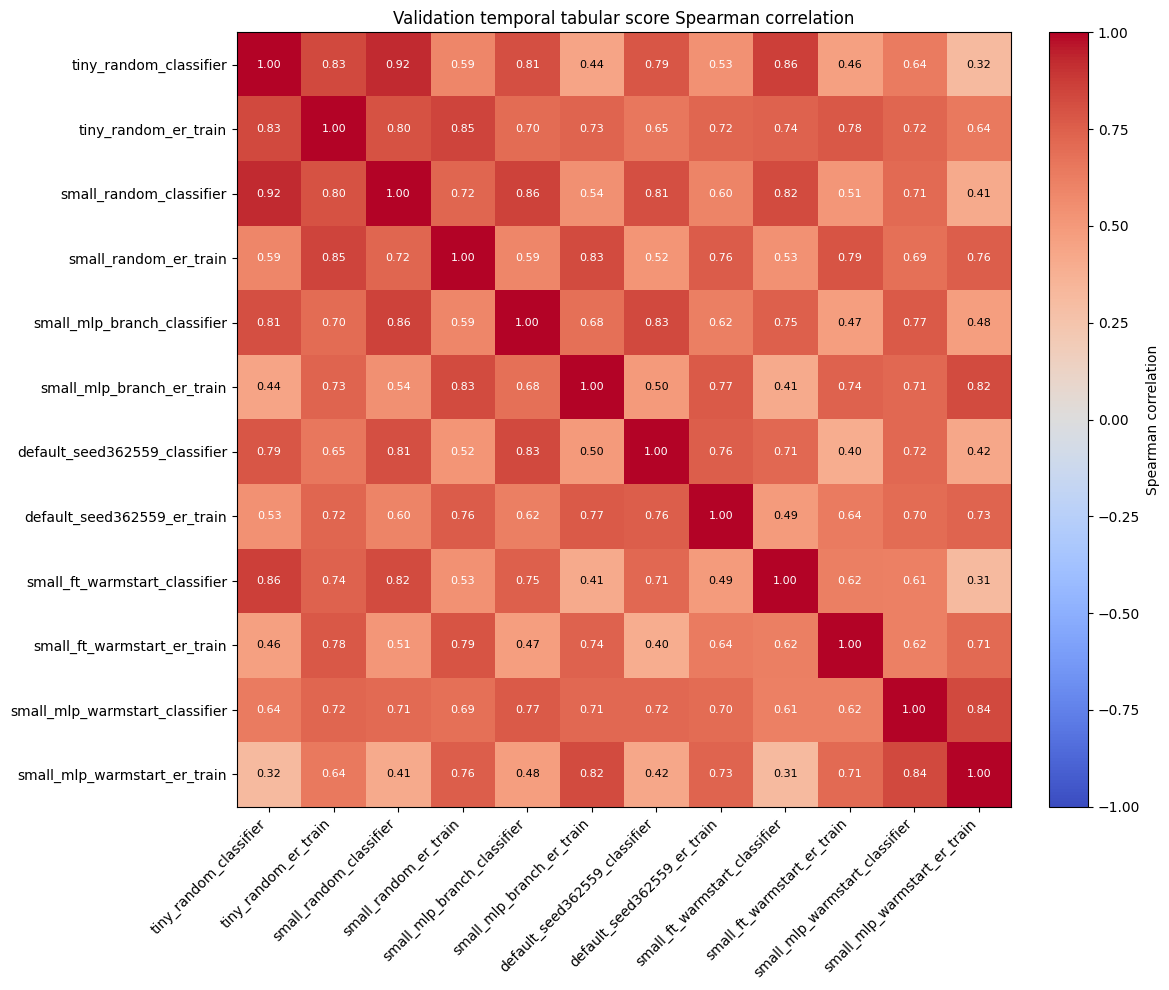

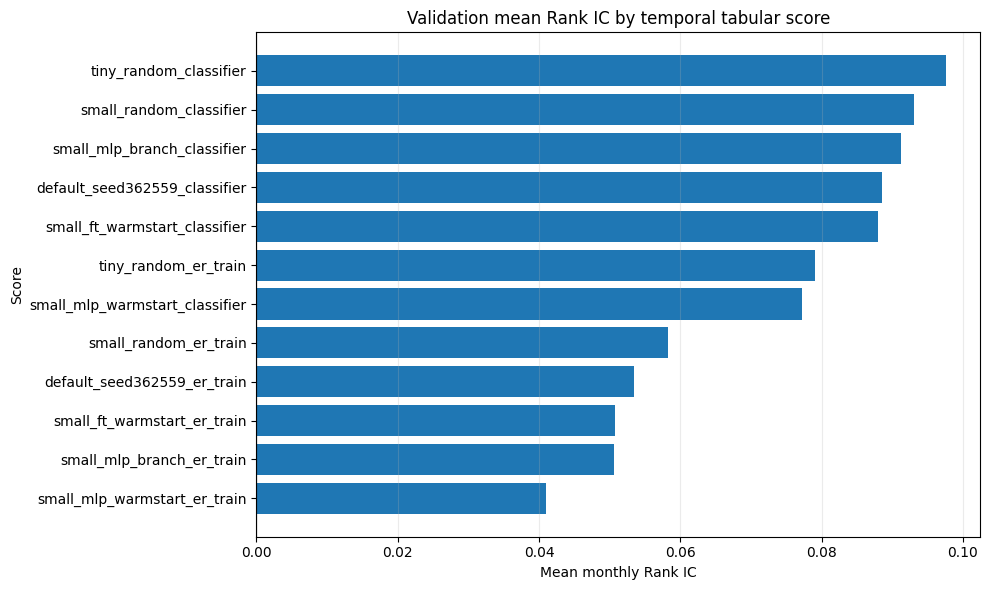

In [11]:
# Cell 11: Validation score correlations and Rank IC chart


def score_correlation_table(data: pd.DataFrame, score_columns: dict[str, str], split: str = "validation") -> pd.DataFrame:
    cols = [col for col in score_columns.values() if col in data.columns]
    labels = {v: k for k, v in score_columns.items()}
    corr = data.loc[data["split"].eq(split), cols].corr(method="spearman")
    return corr.rename(index=labels, columns=labels)


validation_score_corr = score_correlation_table(predictions, score_columns, split="validation")
validation_score_corr.to_csv(BACKTEST_DIR / "validation_temporal_tabular_score_spearman_correlation.csv")
display(validation_score_corr)

if not validation_score_corr.empty:
    fig, ax = plt.subplots(figsize=(12, 10))
    values = validation_score_corr.to_numpy(dtype=float)
    image = ax.imshow(values, cmap="coolwarm", vmin=-1, vmax=1)
    ax.set_xticks(range(len(validation_score_corr.columns)))
    ax.set_yticks(range(len(validation_score_corr.index)))
    ax.set_xticklabels(validation_score_corr.columns, rotation=45, ha="right")
    ax.set_yticklabels(validation_score_corr.index)
    ax.set_title("Validation temporal tabular score Spearman correlation")
    for i in range(validation_score_corr.shape[0]):
        for j in range(validation_score_corr.shape[1]):
            value = values[i, j]
            ax.text(j, i, f"{value:.2f}", ha="center", va="center", color="white" if abs(value) > 0.5 else "black", fontsize=8)
    fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04, label="Spearman correlation")
    fig.tight_layout()
    fig.savefig(FIGURE_DIR / "validation_temporal_tabular_score_spearman_correlation_heatmap.png", dpi=180, bbox_inches="tight")
    plt.show()

rank_ic_plot = validation_rank_ic.sort_values("mean_rank_ic", ascending=True)
fig, ax = plt.subplots(figsize=(10, max(6, 0.35 * len(rank_ic_plot))))
ax.barh(rank_ic_plot["score_label"], rank_ic_plot["mean_rank_ic"])
ax.axvline(0, linewidth=0.8, color="black")
ax.set_title("Validation mean Rank IC by temporal tabular score")
ax.set_xlabel("Mean monthly Rank IC")
ax.set_ylabel("Score")
ax.grid(axis="x", alpha=0.25)
fig.tight_layout()
fig.savefig(FIGURE_DIR / "validation_temporal_tabular_score_rank_ic_bar_chart.png", dpi=160, bbox_inches="tight")
plt.show()


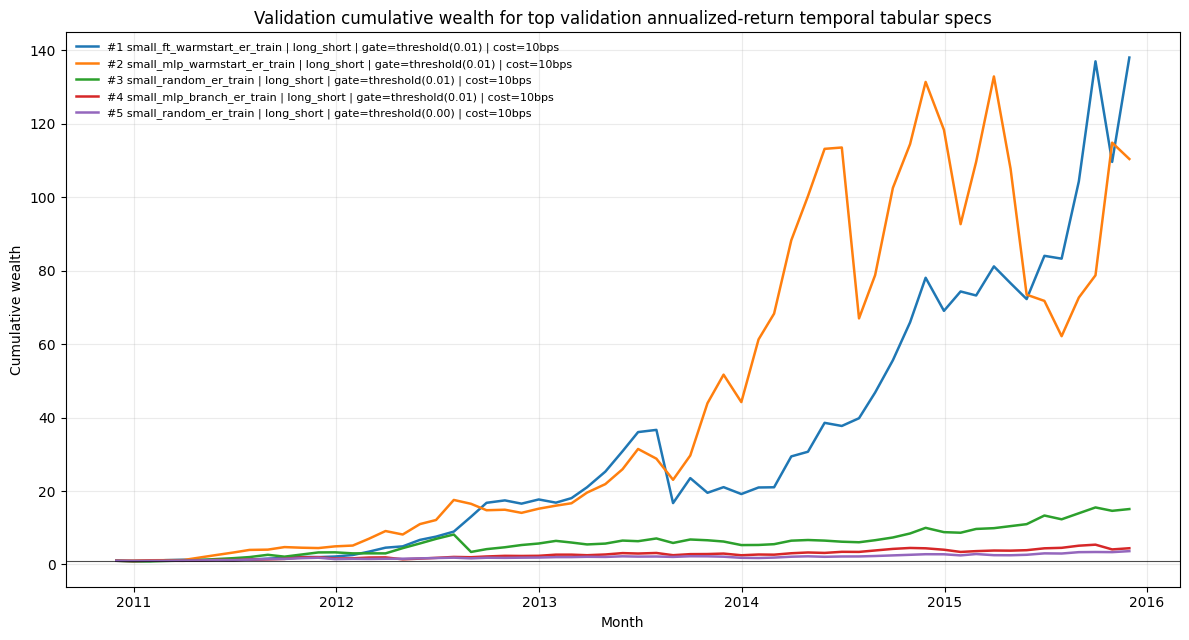

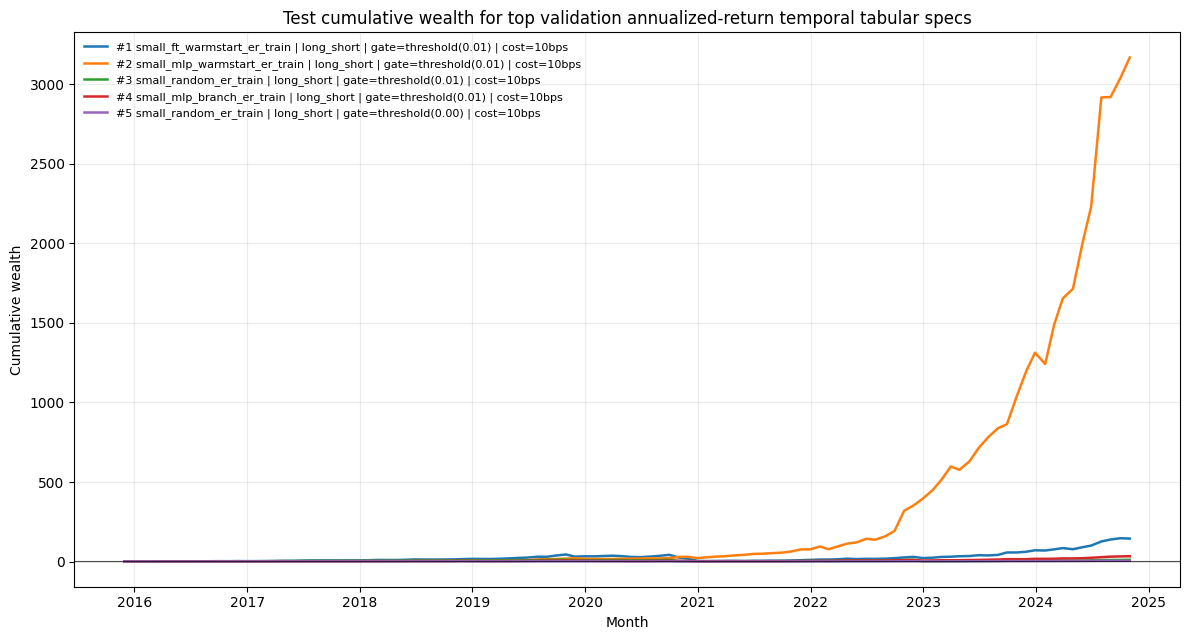

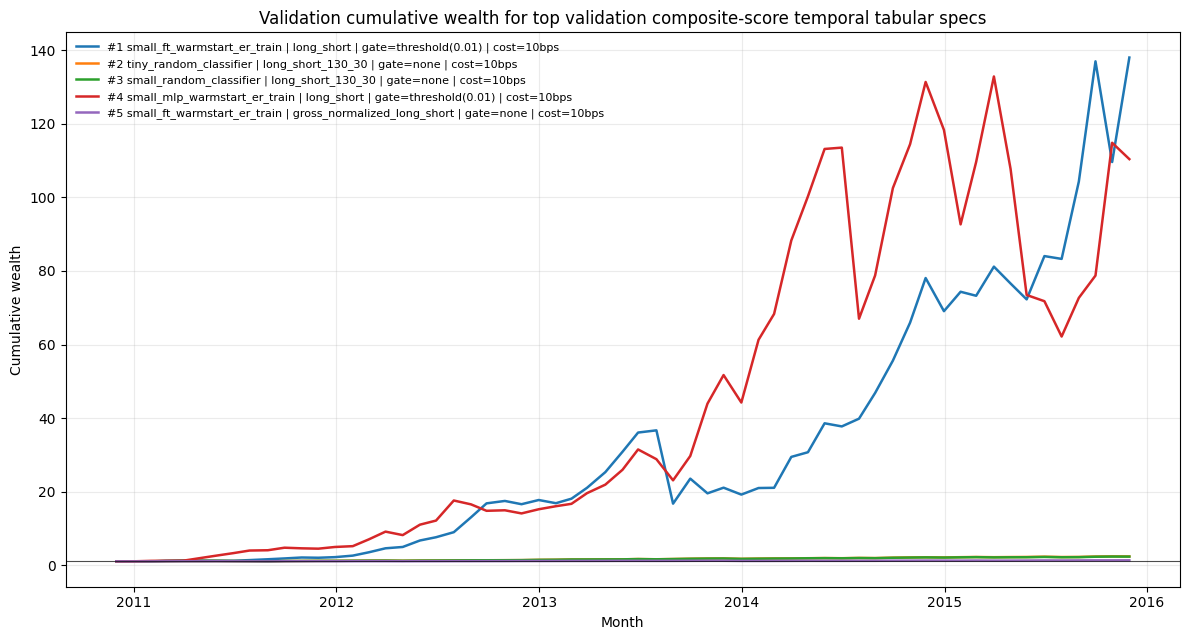

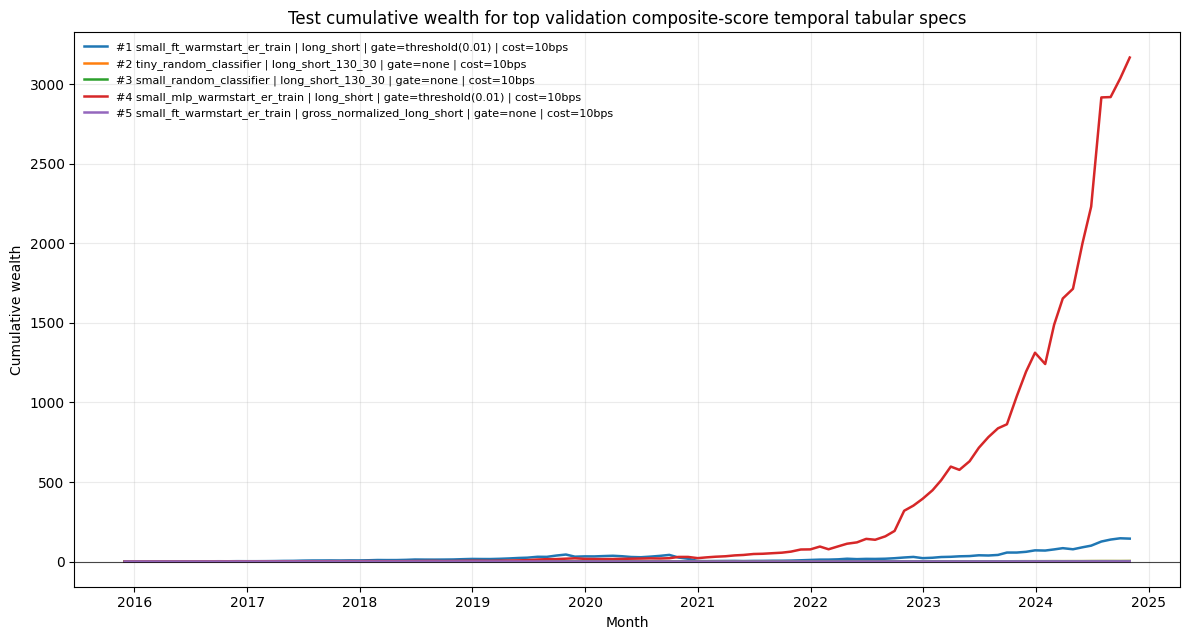

In [12]:
# Cell 12: Plot cumulative wealth for top validation specifications


def spec_filter(monthly: pd.DataFrame, spec: pd.Series, split: str) -> pd.Series:
    return monthly["split"].eq(split) & monthly["score_label"].eq(spec["score_label"]) & monthly["rule"].eq(spec["rule"]) & np.isclose(monthly["q"].astype(float), float(spec["q"])) & monthly["sign_gate"].eq(bool(spec["sign_gate"])) & monthly["threshold_gate"].eq(bool(spec["threshold_gate"])) & np.isclose(monthly["zero_threshold"].astype(float), float(spec["zero_threshold"])) & np.isclose(monthly["one_way_cost_bps"].astype(float), float(spec["one_way_cost_bps"]))


def plot_cumulative_wealth(monthly: pd.DataFrame, specs: pd.DataFrame, split: str, path: Path, title_suffix: str) -> None:
    fig, ax = plt.subplots(figsize=(12, 6.5))
    plotted = 0
    for rank, (_, spec) in enumerate(specs.iterrows(), start=1):
        part = monthly.loc[spec_filter(monthly, spec, split)].sort_values("month")
        if part.empty:
            continue
        month_index = pd.to_datetime(part["month"].to_numpy())
        returns = pd.Series(part["net_return"].fillna(0.0).to_numpy(dtype="float64"), index=month_index)
        start_month = month_index[0] - pd.offsets.MonthBegin(1)
        wealth = pd.concat([pd.Series([1.0], index=[start_month]), (1.0 + returns).cumprod()])
        if spec["threshold_gate"]:
            gate_label = f"threshold({spec['zero_threshold']:.2f})"
        elif spec["sign_gate"]:
            gate_label = "sign"
        else:
            gate_label = "none"
        label = f"#{rank} {spec['score_label']} | {spec['rule']} | gate={gate_label} | cost={spec['one_way_cost_bps']:.0f}bps"
        ax.plot(wealth.index, wealth.values, linewidth=1.8, label=label)
        plotted += 1
    if plotted == 0:
        raise ValueError(f"No cumulative-wealth series found for split={split!r}.")
    ax.axhline(1.0, linewidth=0.8, color="black", alpha=0.7)
    ax.set_title(f"{split.title()} cumulative wealth for {title_suffix}")
    ax.set_xlabel("Month")
    ax.set_ylabel("Cumulative wealth")
    ax.legend(fontsize=8, frameon=False, loc="best")
    ax.grid(alpha=0.25)
    fig.tight_layout()
    fig.savefig(path, dpi=160, bbox_inches="tight")
    plt.show()


top5_annual_return_specs = selection_table.head(5)[SPEC_COLUMNS].copy()
top5_composite_specs = selection_table.sort_values(["validation_composite_score", "validation_net_annualized_return", "validation_net_sharpe"], ascending=[False, False, False]).head(5)[SPEC_COLUMNS].copy()
plot_cumulative_wealth(portfolio_monthly, top5_annual_return_specs, "validation", FIGURE_DIR / "validation_top5_annual_return_temporal_tabular_strategy_cumulative_wealth.png", "top validation annualized-return temporal tabular specs")
plot_cumulative_wealth(portfolio_monthly, top5_annual_return_specs, "test", FIGURE_DIR / "test_top5_annual_return_temporal_tabular_strategy_cumulative_wealth.png", "top validation annualized-return temporal tabular specs")
plot_cumulative_wealth(portfolio_monthly, top5_composite_specs, "validation", FIGURE_DIR / "validation_top5_composite_temporal_tabular_strategy_cumulative_wealth.png", "top validation composite-score temporal tabular specs")
plot_cumulative_wealth(portfolio_monthly, top5_composite_specs, "test", FIGURE_DIR / "test_top5_composite_temporal_tabular_strategy_cumulative_wealth.png", "top validation composite-score temporal tabular specs")


In [13]:
# Cell 13: Output manifest

output_manifest = pd.DataFrame(
    [
        {"artifact": "merged_predictions", "path": PREDICTION_DIR / "temporal_tabular_backtest_predictions.parquet"},
        {"artifact": "loaded_runs", "path": TABLE_DIR / "temporal_tabular_backtest_loaded_runs.csv"},
        {"artifact": "prediction_coverage", "path": TABLE_DIR / "temporal_tabular_backtest_prediction_coverage.csv"},
        {"artifact": "monthly_rank_ic", "path": BACKTEST_DIR / "temporal_tabular_score_monthly_rank_ic.csv"},
        {"artifact": "rank_ic_summary", "path": BACKTEST_DIR / "temporal_tabular_score_rank_ic_summary.csv"},
        {"artifact": "monthly_returns", "path": BACKTEST_DIR / "temporal_tabular_score_strategy_monthly_returns.csv"},
        {"artifact": "performance_summary", "path": BACKTEST_DIR / "temporal_tabular_score_strategy_performance_summary.csv"},
        {"artifact": "validation_ranking", "path": BACKTEST_DIR / "validation_temporal_tabular_score_strategy_ranking.csv"},
        {"artifact": "selection_table_10bps", "path": BACKTEST_DIR / "validation_temporal_tabular_selection_table_10bps.csv"},
        {"artifact": "chosen_validation_spec", "path": BACKTEST_DIR / "chosen_validation_temporal_tabular_specification.csv"},
        {"artifact": "chosen_test_performance", "path": BACKTEST_DIR / "test_performance_of_chosen_validation_temporal_tabular_spec.csv"},
        {"artifact": "figures", "path": FIGURE_DIR},
    ]
)
output_manifest["path"] = output_manifest["path"].map(lambda p: str(Path(p).relative_to(REPO_ROOT)))
output_manifest.to_csv(BACKTEST_DIR / "temporal_tabular_backtest_output_manifest.csv", index=False)
display(output_manifest)
print("Temporal tabular backtest complete.")


,artifact,path
0,merged_predictions,outputs/predictions/temporal_tabular_backtest_...
1,loaded_runs,outputs/tables/temporal_tabular_backtest_loade...
2,prediction_coverage,outputs/tables/temporal_tabular_backtest_predi...
3,monthly_rank_ic,outputs/backtests/temporal_tabular_score_strat...
4,rank_ic_summary,outputs/backtests/temporal_tabular_score_strat...
5,monthly_returns,outputs/backtests/temporal_tabular_score_strat...
6,performance_summary,outputs/backtests/temporal_tabular_score_strat...
7,validation_ranking,outputs/backtests/temporal_tabular_score_strat...
8,selection_table_10bps,outputs/backtests/temporal_tabular_score_strat...
9,chosen_validation_spec,outputs/backtests/temporal_tabular_score_strat...


Temporal tabular backtest complete.
